# Sanity Checks — Condition Model

This notebook verifies the **logical correctness** of the core pipeline files:
`dataset.py`, `loss.py`, `cond_sampler.py`, `forecasting.py`, `utils.py`.

Every check targets a specific invariant that **must hold by construction** if the
logic is correct.  Failures point directly at bugs in the named module.


In [ ]:
import sys, math
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

ROOT = Path('..').resolve()          # repo root
sys.path.insert(0, str(ROOT / 'Condition_model'))

from dataset      import SQGLeadTimeDataset, DATA_500
from loss         import flow_matching_loss
from cond_sampler import CondSampler
from forecasting  import forecasting, get_latent
from utils        import compute_rmse, compute_crps, compute_ssr
from diffusion_networks import SongUNet

# ── shared config ────────────────────────────────────────────────────────────
DATA_DIR     = DATA_500
DATA_STD     = 2660.0
MODEL_PATH   = ROOT / 'models' / 'ep40on500traj.pth'
BATCH_SIZE   = 16
MAX_HORIZON  = 99          # matches training
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'device : {DEVICE}')
print(f'data   : {DATA_DIR}')

device : cuda
data   : /home/trace/Documents/Projects/Thesis/data_500traj


---
## 1  `dataset.py` — `SQGLeadTimeDataset`

### 1-A  Shape and split sizes

**Why:** The dataset exposes two distinct modes (train / eval) with completely
different return signatures.  A wrong shape would silently corrupt every
downstream computation (loss, sampler, metrics).  We also verify that train and
val together cover the expected number of trajectory files and that neither set
is empty.

**Config:** `split='train'`, `split='val'`, default `max_lead_frames=99`.

In [2]:
train_ds = SQGLeadTimeDataset(DATA_DIR, std=DATA_STD, split='train')
val_ds   = SQGLeadTimeDataset(DATA_DIR, std=DATA_STD, split='val')

prev, curr, tl = train_ds[0]
print('=== Train mode single sample ===')
print(f'  prev  shape : {tuple(prev.shape)}   expect (2, 64, 64)')
print(f'  curr  shape : {tuple(curr.shape)}   expect (2, 64, 64)')
print(f'  tl    shape : {tl.shape}  ndim={tl.ndim}   expect scalar (ndim=0)')
print(f'  tl    value : {tl.item():.4f}   expect in (0, 1]')

n_traj_train = len(train_ds.data)
n_traj_val   = len(val_ds.data)
print(f'\nTrajectories  train={n_traj_train}  val={n_traj_val}')
print(f'Pairs         train={len(train_ds)}   expect={n_traj_train * MAX_HORIZON}')
print(f'Pairs         val  ={len(val_ds)}     expect={n_traj_val   * MAX_HORIZON}')

assert prev.shape  == (2, 64, 64)
assert curr.shape  == (2, 64, 64)
assert tl.ndim     == 0
assert 0 < tl.item() <= 1
assert len(train_ds) == n_traj_train * MAX_HORIZON
print('\n[PASS] shapes and split sizes')

=== Train mode single sample ===
  prev  shape : (2, 64, 64)   expect (2, 64, 64)
  curr  shape : (2, 64, 64)   expect (2, 64, 64)
  tl    shape : torch.Size([])  ndim=0   expect scalar (ndim=0)
  tl    value : 0.0101   expect in (0, 1]

Trajectories  train=400  val=100
Pairs         train=39600   expect=39600
Pairs         val  =9900     expect=9900

[PASS] shapes and split sizes


### 1-B  Normalization: std ≈ 1, mean ≈ 0

**Why:** `flow_matching_loss` assumes the interpolant endpoints have unit scale
(z0 ~ N(0,I) and x_{t+1} ~ unit scale).  If the raw SQG data (order 2660) were
fed in without dividing by `std=2660`, the velocity target `x_{t+1} - z0` would
have magnitude ~2660 instead of ~1, making the loss thousands of times larger
and the score function estimate completely wrong.  This check catches any
mis-wiring of the `std` argument.

**Config:** pool 200 random train samples; check both channels.

In [3]:
N_SAMPLES = 200
rng = np.random.default_rng(0)
idx = rng.integers(0, len(train_ds), N_SAMPLES)

frames = torch.stack([train_ds[i][0] for i in idx])  # (N, 2, 64, 64)
mean_all = frames.mean().item()
std_all  = frames.std().item()

print(f'Pooled over {N_SAMPLES} samples:')
print(f'  mean = {mean_all:.4f}   expect ≈ 0')
print(f'  std  = {std_all:.4f}   expect ≈ 1')

assert abs(mean_all) < 0.1,  f'mean too far from 0: {mean_all:.4f}'
assert 0.5 < std_all < 1.5,  f'std not near 1: {std_all:.4f}'
print('\n[PASS] normalization')

Pooled over 200 samples:
  mean = -0.0000   expect ≈ 0
  std  = 1.0008   expect ≈ 1

[PASS] normalization


### 1-C  Lead-time label formula: `tl = k / max_horizon`

**Why:** The model is conditioned on the normalized lead time passed as
`time_labels`.  If the formula `k / max_horizon` is wrong — e.g., off-by-one
(`k-1`), or using the wrong denominator — every `time_emb` embedding is
corrupted, and the model cannot distinguish short from long leads.

**Config:** Manually construct a dataset and inspect known pairs.  
For k=1: tl should be 1/99 ≈ 0.0101.  For k=99: tl should be 1.0.

In [4]:
# In training mode, _pairs[i] = (traj_idx, k).  The time label is k/max_horizon.
# Find the samples with k=1 and k=99 from the first trajectory.
_, _, tl_k1  = train_ds[0]
_, _, tl_k99 = train_ds[-1]

print(f'k=1  tl={tl_k1.item():.6f}   expect {1/MAX_HORIZON:.6f}')
print(f'k=99 tl={tl_k99.item():.6f}  expect {99/MAX_HORIZON:.6f}')

assert abs(tl_k1.item()  - 1/MAX_HORIZON)  < 1e-5
assert abs(tl_k99.item() - 99/MAX_HORIZON) < 1e-5
print('\n[PASS] lead-time label formula')

k=1  tl=0.010101   expect 0.010101
k=99 tl=1.000000  expect 1.000000

[PASS] lead-time label formula


### 1-D  Anchor+k indexing: `x_t1 = trajectory[0 + k]`

**Why:** The whole training setup is conditional forecasting `p(x_{t+k} | x_t)`.
If the dataset accidentally returns the wrong future frame (e.g., frame 0+k-1
instead of 0+k, or uses a different anchor), the model learns to predict the
wrong target.  We verify by directly comparing the tensor returned by the
dataset to a manually sliced frame from the raw trajectory.

**Config:** Trajectory index 0, leads k=1 and k=10.

In [5]:
traj0 = train_ds.data[0]   # (T, 2, 64, 64)  already normalized

for k in [1, 10, 50]:
    idx_pair = next(i for i, (ti, ki) in enumerate(train_ds._pairs)
                    if ti == 0 and ki == k)
    prev_ret, curr_ret, tl_ret = train_ds[idx_pair]

    expected_prev = traj0[0]   # anchor = frame 0
    expected_curr = traj0[k]   # target = frame k

    err_prev = (prev_ret - expected_prev).abs().max().item()
    err_curr = (curr_ret - expected_curr).abs().max().item()
    print(f'k={k:2d}  prev_err={err_prev:.2e}  curr_err={err_curr:.2e}  (expect ~0)')
    assert err_prev < 1e-6, f'k={k}: anchor mismatch'
    assert err_curr < 1e-6, f'k={k}: target mismatch'

print('\n[PASS] anchor+k indexing')

k= 1  prev_err=0.00e+00  curr_err=0.00e+00  (expect ~0)
k=10  prev_err=0.00e+00  curr_err=0.00e+00  (expect ~0)
k=50  prev_err=0.00e+00  curr_err=0.00e+00  (expect ~0)

[PASS] anchor+k indexing


### 1-E  Eval-mode shape and lead label ordering

**Why:** `forecasting.py::predict` relies on the eval-mode dataset returning
`truth[j]` aligned with `time_labels[j]`.  If the ordering is wrong, every
RMSE / CRPS / SSR is computed against the wrong ground-truth frame.

**Config:** `forecasting_leads=[1, 10, 50]`, `n_init=5`.

In [6]:
LEADS = [1, 10, 50]
eval_ds = SQGLeadTimeDataset(
    DATA_DIR, std=DATA_STD, split='val',
    random_lead_time=False,
    forecasting_leads=LEADS,
    n_init=5, seed=0,
)

x0, truth, tls = eval_ds[0]
print(f'x0    shape : {tuple(x0.shape)}         expect (2, 64, 64)')
print(f'truth shape : {tuple(truth.shape)}   expect ({len(LEADS)}, 2, 64, 64)')
print(f'tls   shape : {tuple(tls.shape)}         expect ({len(LEADS)},)')
print(f'tls   values: {[round(v,4) for v in tls.tolist()]}')
print(f'      expect: {[round(k/MAX_HORIZON,4) for k in LEADS]}')

assert tuple(truth.shape) == (len(LEADS), 2, 64, 64)
assert tuple(tls.shape)   == (len(LEADS),)
for j, k in enumerate(LEADS):
    assert abs(tls[j].item() - k/MAX_HORIZON) < 1e-5, (
        f'label mismatch at j={j}: got {tls[j].item():.5f}, expect {k/MAX_HORIZON:.5f}')


x0    shape : (2, 64, 64)         expect (2, 64, 64)
truth shape : (3, 2, 64, 64)   expect (3, 2, 64, 64)
tls   shape : (3,)         expect (3,)
tls   values: [0.0101, 0.101, 0.5051]
      expect: [0.0101, 0.101, 0.5051]


---
## 2  `cond_sampler.py` — `CondSampler`

**Note:** These checks require a trained checkpoint at `MODEL_PATH`.

### 2-A  (Completed) Sampler produces a forecast

**Why:** The existing incomplete check in the original notebook left the loop
body empty.  We complete it: verify the sampler returns a tensor of the correct
shape, in a plausible value range (normalized, so roughly ±5 is fine), and that
RMSE vs truth is finite and non-trivially small.

**Config:** eval-mode dataset, leads [1, 10, 50], 3 initial conditions, 1 ensemble member.

 Lead      RMSE   out_std
    1    0.0994    1.1492
   50    0.8774    1.0098
   99    1.1856    0.9841

[PASS] sampler produces valid forecasts


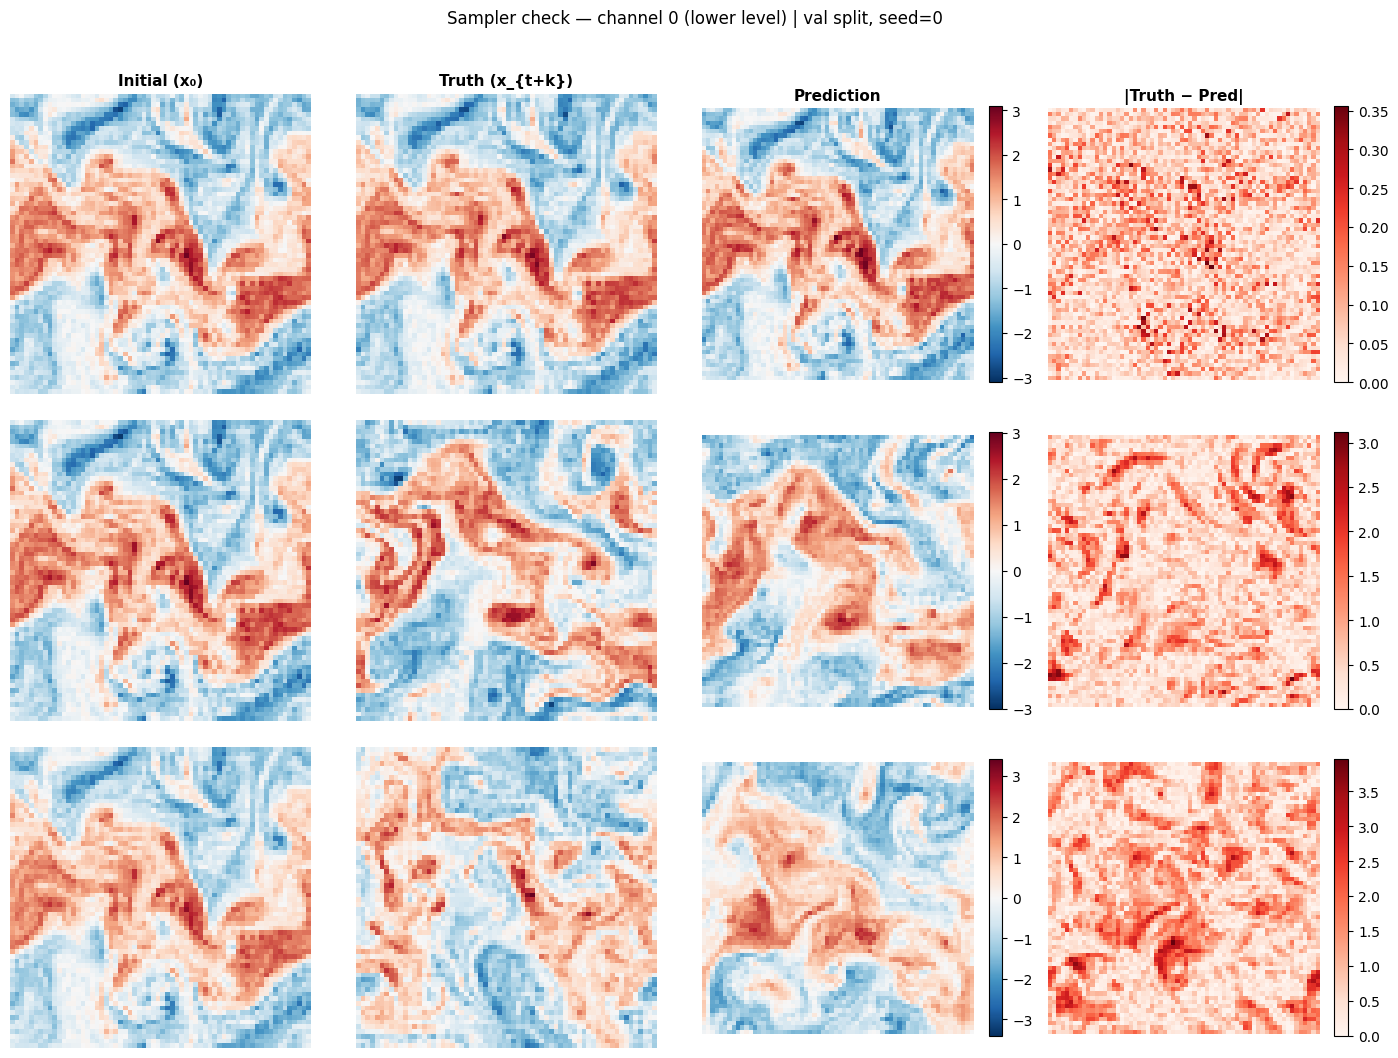

In [2]:
import itertools
import math

EVAL_LEADS = [1, 50, 99]
check_ds = SQGLeadTimeDataset(
    DATA_DIR, std=DATA_STD, split='val',
    random_lead_time=False, forecasting_leads=EVAL_LEADS,
    n_init=3, seed=0,
)
check_loader = DataLoader(check_ds, batch_size=1, shuffle=False, num_workers=0)
sampler = CondSampler(model_path=MODEL_PATH, device=DEVICE, steps=100, eps=None)

print(f'{"Lead":>5}  {"RMSE":>8}  {"out_std":>8}')

# collect for visualization
records = []   # list of dicts: {k, initial, truth, pred}

for initial, target, tl in itertools.islice(check_loader, 1):   # use first IC only
    initial = initial.to(DEVICE)
    for j, k in enumerate(EVAL_LEADS):
        lead_label = tl[:, j].to(DEVICE)
        z0   = torch.randn_like(initial)
        pred = sampler.sample(z0=z0, x_t=initial, lead_times=lead_label).to(DEVICE)
        assert pred.shape == initial.shape, f'Shape mismatch: {pred.shape}'

        truth_k = target[:, j].to(DEVICE)
        rmse    = (pred - truth_k).pow(2).mean().sqrt().item()
        print(f'{k:5d}  {rmse:8.4f}  {pred.std().item():8.4f}')
        assert math.isfinite(rmse), 'RMSE is not finite — NaN in output'
        assert pred.std().item() > 0.01, 'Output collapsed'

        records.append({
            'k':       k,
            'initial': initial[0, 0].cpu().numpy(),   # (H, W) channel 0
            'truth':   truth_k[0, 0].cpu().numpy(),
            'pred':    pred[0, 0].cpu().numpy(),
            'diff':    (pred - truth_k)[0, 0].abs().cpu().numpy(),
            'rmse':    rmse,
        })

print('\n[PASS] sampler produces valid forecasts')

# ── Visualization ────────────────────────────────────────────────────────────
# Layout: one row per lead, four columns: x0 | truth | pred | |diff|
n_leads = len(EVAL_LEADS)
fig, axes = plt.subplots(n_leads, 4, figsize=(14, 3.5 * n_leads))

col_titles = ['Initial (x₀)', 'Truth (x_{t+k})', 'Prediction', '|Truth − Pred|']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold')

for row, rec in enumerate(records):
    # shared color scale for x0/truth/pred
    vmax = max(abs(rec['truth']).max(), abs(rec['pred']).max(),
               abs(rec['initial']).max())
    kw_field = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    kw_diff  = dict(cmap='Reds',   vmin=0,     vmax=rec['diff'].max())

    im0 = axes[row, 0].imshow(rec['initial'], **kw_field)
    im1 = axes[row, 1].imshow(rec['truth'],   **kw_field)
    im2 = axes[row, 2].imshow(rec['pred'],    **kw_field)
    im3 = axes[row, 3].imshow(rec['diff'],    **kw_diff)

    fig.colorbar(im2, ax=axes[row, 2], fraction=0.046)
    fig.colorbar(im3, ax=axes[row, 3], fraction=0.046)

    axes[row, 0].set_ylabel(f'lead = {rec["k"]:2d}\nRMSE={rec["rmse"]:.3f}',
                            fontsize=10)
    for col in range(4):
        axes[row, col].axis('off')

plt.suptitle('Sampler check — channel 0 (lower level) | val split, seed=0',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


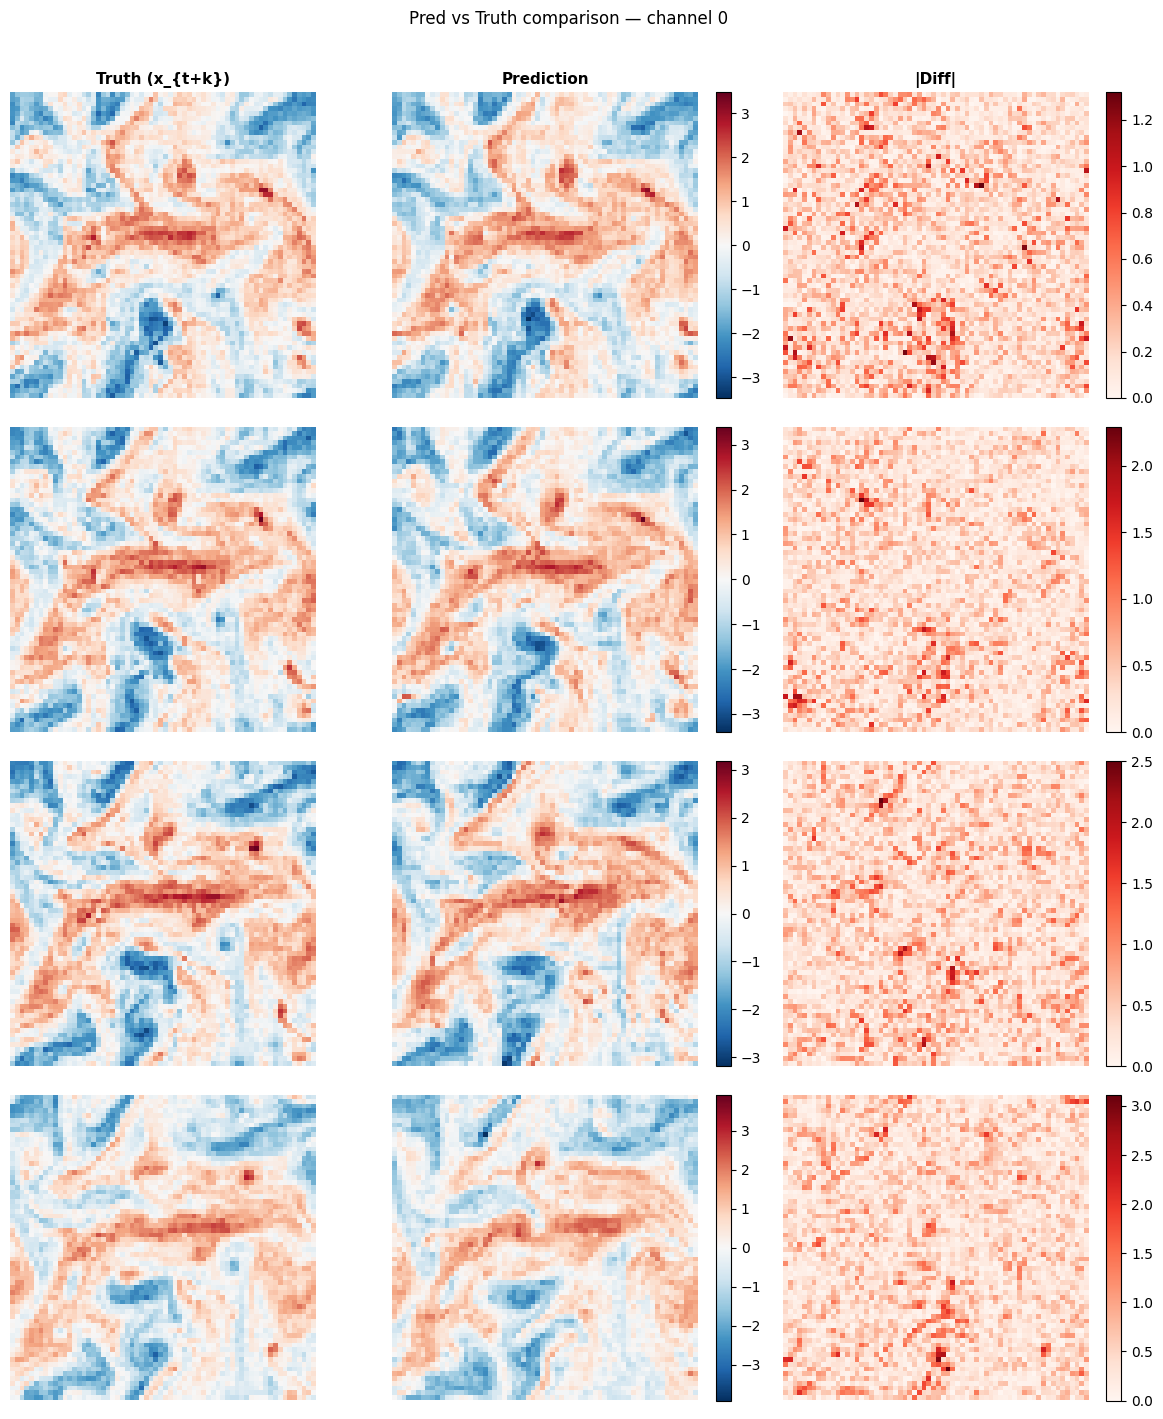

In [25]:
# let's try whether can I implement the parallelization and whether this code support it
# i cannot
# this code cannot neither..... 

# Create dataset in EVAL mode
dataset = SQGLeadTimeDataset(
    data_dir=DATA_DIR,
    split='val',                          # validation split
    random_lead_time=False,               # ← eval mode (key!)
    forecasting_leads=[6, 12, 18, 24],   # ← 4 different lead times (frames)
    n_init=10,                            # 10 different initial conditions
    seed=42,
)

# Extract a single sample (one initial condition + 4 future targets)
x0, targets, time_labels = dataset[0]


# Access individual future frames by lead index:
# frame_at_lead_1  = targets[0]      # (2, 64, 64)
# frame_at_lead_25 = targets[1]      # (2, 64, 64)
# frame_at_lead_50 = targets[2]      # (2, 64, 64)
# frame_at_lead_99 = targets[3]      # (2, 64, 64)
x0 = torch.stack([x0] * 4)
z0   = torch.randn_like(x0)
pred = sampler.sample(z0=z0, x_t=x0, lead_times=time_labels)

pred = pred.cpu().numpy()
x0 = x0.cpu().numpy()
targets = targets.cpu().numpy()
diff = (pred - targets)

# the sampler doesn't support parallelization of course.
# it actuall can......

# ── Visualization: Truth | Pred | |Diff| ────────────────────────────────────
n_rows = len(pred)
fig, axes = plt.subplots(n_rows, 3, figsize=(12, 3.5 * n_rows))

col_titles = ['Truth (x_{t+k})', 'Prediction', '|Diff|']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold')

for row in range(n_rows):
    truth_ch0 = targets[row, 0]      # channel 0
    pred_ch0 = pred[row, 0]
    diff_ch0 = np.abs(diff[row, 0])
    
    # Shared color scale for truth/pred
    vmax_field = max(abs(truth_ch0).max(), abs(pred_ch0).max())
    kw_field = dict(cmap='RdBu_r', vmin=-vmax_field, vmax=vmax_field)
    kw_diff = dict(cmap='Reds', vmin=0, vmax=diff_ch0.max())

    im1 = axes[row, 0].imshow(truth_ch0, **kw_field)
    im2 = axes[row, 1].imshow(pred_ch0, **kw_field)
    im3 = axes[row, 2].imshow(diff_ch0, **kw_diff)

    fig.colorbar(im2, ax=axes[row, 1], fraction=0.046)
    fig.colorbar(im3, ax=axes[row, 2], fraction=0.046)

    lead_idx = row
    rmse = np.sqrt(((pred[row] - targets[row]) ** 2).mean())
    axes[row, 0].set_ylabel(f'lead={lead_idx}\nRMSE={rmse:.3f}', fontsize=10)
    for col in range(3):
        axes[row, col].axis('off')

plt.suptitle('Pred vs Truth comparison — channel 0', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 2-B  Determinism: same seed → same output

**Why:** `CondSampler.sample` with `eps=None` is a deterministic ODE.  Given
the same initial noise z0 and same conditioning, it must return bit-identical
results.  Non-determinism would mean the sampler contains accidental random ops
(e.g., un-seeded randn, dropout left on), breaking reproducibility and making
ensemble construction unreliable.

**Config:** single initial condition; call sample() twice with same z0.

In [8]:
x0_single, _, tl_single = check_ds[0]
x0_b = x0_single.unsqueeze(0).to(DEVICE)   # (1,2,64,64)
lead = tl_single[:1].to(DEVICE)            # lead for first lead index

torch.manual_seed(99)
z0_fixed = torch.randn_like(x0_b)

pred_1 = sampler.sample(z0=z0_fixed.clone(), x_t=x0_b, lead_times=lead)
pred_2 = sampler.sample(z0=z0_fixed.clone(), x_t=x0_b, lead_times=lead)

max_diff = (pred_1 - pred_2).abs().max().item()
print(f'Max abs diff between two identical calls: {max_diff:.2e}   expect 0.0')
assert max_diff == 0.0, 'Sampler is non-deterministic!'
print('\n[PASS] sampler is deterministic')

Max abs diff between two identical calls: 0.00e+00   expect 0.0

[PASS] sampler is deterministic


### 2-C  Lead-time sensitivity: different lead → different output

**Why:** If the model ignores `time_labels` (e.g., `time_emb` was 0 at training
or the lead is not passed correctly), every lead produces the same forecast.
This would make the model useless for continuous forecasting — it could only
ever predict one fixed horizon.  We verify outputs genuinely differ when the
lead-time label changes, holding z0 and x_t fixed.

**Config:** same z0 and x_t; compare lead k=1 vs k=50.

In [9]:
lead_short = torch.tensor([1  / MAX_HORIZON], dtype=torch.float32, device=DEVICE)
lead_long  = torch.tensor([50 / MAX_HORIZON], dtype=torch.float32, device=DEVICE)

torch.manual_seed(42)
z0_test = torch.randn_like(x0_b)

pred_short = sampler.sample(z0=z0_test.clone(), x_t=x0_b, lead_times=lead_short)
pred_long  = sampler.sample(z0=z0_test.clone(), x_t=x0_b, lead_times=lead_long)

mean_diff = (pred_short - pred_long).abs().mean().item()
print(f'Mean abs diff (lead=1 vs lead=50) : {mean_diff:.4f}   expect > 0.01')
assert mean_diff > 0.01, 'Model ignores lead-time conditioning!'
print('\n[PASS] model is lead-time sensitive')

Mean abs diff (lead=1 vs lead=50) : 0.8789   expect > 0.01

[PASS] model is lead-time sensitive


### 2-D  Ensemble spread comes from latent noise diversity

**Why:** The entire probabilistic forecasting strategy relies on different z0
samples producing different ensemble members.  If the model has collapsed to a
deterministic mapping (ignoring z0), all members are identical and SSR = 0
regardless of the lead time.  This check verifies spread > 0 for N=10 members
with independent z0.

**Config:** N=10 ensemble members, 1 initial condition, lead=10.

Ensemble spread (N=10, lead=10) : 0.2236   expect > 0.01


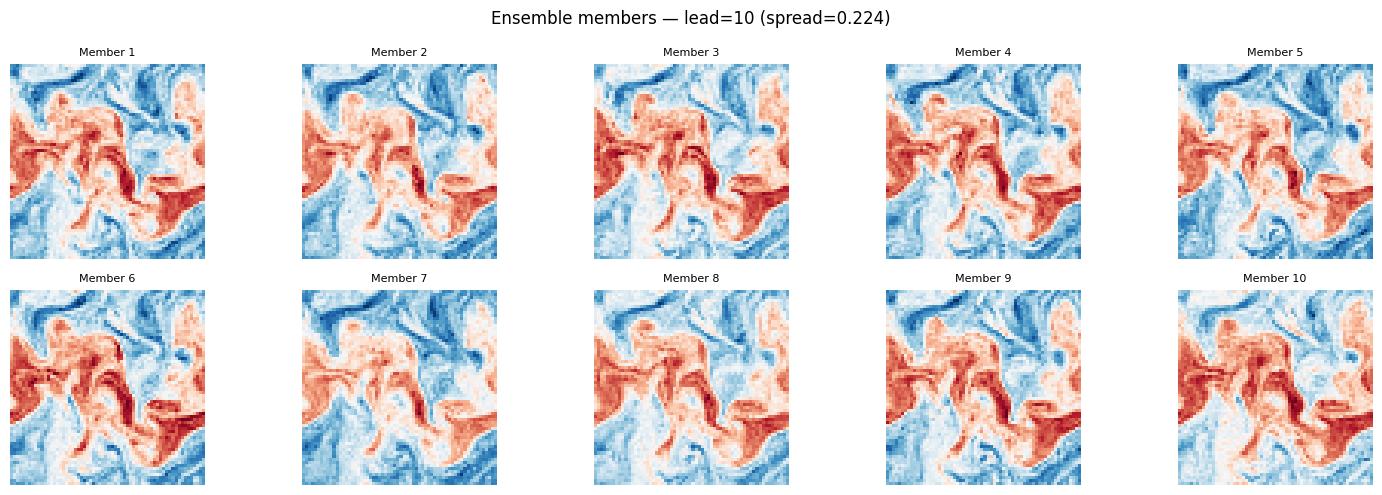


[PASS] ensemble spread > 0


In [10]:
N_ENS   = 10
lead_10 = torch.tensor([10 / MAX_HORIZON], dtype=torch.float32, device=DEVICE)
x0_ens  = x0_b.expand(N_ENS, -1, -1, -1).clone()

torch.manual_seed(0)
z0_ens = torch.randn(N_ENS, 2, 64, 64, device=DEVICE)   # independent noise per member
lead_ens = lead_10.expand(N_ENS)

preds_ens = sampler.sample(z0=z0_ens, x_t=x0_ens, lead_times=lead_ens)  # (N,2,64,64)

# Spread = pixel-wise std over members, then spatially averaged
spread = preds_ens.std(dim=0).mean().item()
print(f'Ensemble spread (N={N_ENS}, lead=10) : {spread:.4f}   expect > 0.01')

# Also visualize member diversity
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
for i in range(N_ENS):
    axes[i//5, i%5].imshow(preds_ens[i, 0].cpu().numpy(), cmap='RdBu_r')
    axes[i//5, i%5].set_title(f'Member {i+1}', fontsize=8)
    axes[i//5, i%5].axis('off')
plt.suptitle(f'Ensemble members — lead=10 (spread={spread:.3f})')
plt.tight_layout()
plt.show()

assert spread > 0.01, 'Ensemble has near-zero spread — model collapsed to mean'
print('\n[PASS] ensemble spread > 0')

### 2-E  Score function formula: `(s*b - z_s) / (1-s)`

**Why:** The analytic score is derived from the Gaussian base distribution.
If the formula is inverted or has a sign error, the SDE sampler (eps > 0)
pushes particles in the wrong direction — away from the data distribution.
We verify the formula algebraically using a synthetic oracle where we know
the exact score.

**Config:** synthetic tensors where z1 and z0 are known; verify at s=0.5.

In [11]:
torch.manual_seed(1)
z0_syn  = torch.randn(1, 2, 8, 8)
z1_syn  = torch.randn(1, 2, 8, 8)   # "x_{t+1}"
s_val   = 0.5

# Build z_s at s=0.5
z_s_syn = (1 - s_val) * z0_syn + s_val * z1_syn

# True velocity (oracle)
b_oracle = z1_syn - z0_syn

# Analytic score: s(z_s) = (s*b - z_s) / (1 - s)
score_formula = (s_val * b_oracle - z_s_syn) / (1 - s_val)

# Ground truth score for z_s | z_1 ~ N(s*z_1, (1-s)^2 I):
# s(z_s) = -(z_s - s*z_1) / (1-s)^2  (exact for Gaussian conditional)
score_exact = -(z_s_syn - s_val * z1_syn) / (1 - s_val)**2

err = (score_formula - score_exact).abs().max().item()
print(f'Max error of score formula vs exact: {err:.2e}   expect ~0')
assert err < 1e-5, f'Score formula incorrect: max_err={err:.2e}'
print('\n[PASS] score function formula matches exact Gaussian score')

Max error of score formula vs exact: 2.38e-07   expect ~0

[PASS] score function formula matches exact Gaussian score


---
## 3  `forecasting.py` — OU latent and ensemble pipeline

### 3-A  `get_latent`: OU process preserves N(0,I) marginals

**Why:** `get_latent` implements a discrete-time OU process:
`z_next = rho * z_prev + sqrt(1-rho²) * xi`.  If the `sqrt(1-rho²)` factor
is wrong (e.g., `1-rho` instead of `sqrt(1-rho²)`), the marginal variance
shrinks with every step, eventually collapsing to the first z_prev.  This
breaks ensemble generation: all members converge to the same trajectory.
We verify the marginal std stays ≈ 1 over 100 steps for rho=0.9.

**Config:** shape=(100, 2, 8, 8), rho=0.9, 100 time steps, 1000 replications.

Std over 100 OU steps (rho=0.9):
  mean std = 1.0046   expect ≈ 1.0
  min  std = 0.9851
  max  std = 1.0176


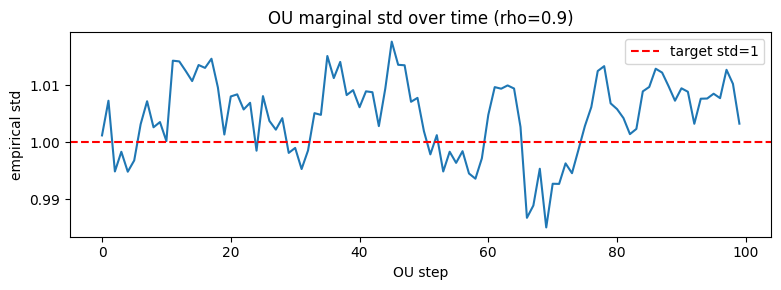


[PASS] OU process preserves N(0,I) marginals


In [12]:
shape  = (50, 2, 8, 8)   # 50 "ensemble members"
rho    = 0.9
T_STEPS = 100

torch.manual_seed(0)
z = None
stds = []
for t in range(T_STEPS):
    z = get_latent(z, shape, rho=rho, device=torch.device('cpu'))
    stds.append(z.std().item())

stds = np.array(stds)
print(f'Std over {T_STEPS} OU steps (rho={rho}):')
print(f'  mean std = {stds.mean():.4f}   expect ≈ 1.0')
print(f'  min  std = {stds.min():.4f}')
print(f'  max  std = {stds.max():.4f}')

plt.figure(figsize=(8,3))
plt.plot(stds)
plt.axhline(1.0, color='red', linestyle='--', label='target std=1')
plt.xlabel('OU step'); plt.ylabel('empirical std'); plt.legend()
plt.title(f'OU marginal std over time (rho={rho})')
plt.tight_layout(); plt.show()

assert abs(stds.mean() - 1.0) < 0.15, f'OU marginal std drifted: {stds.mean():.4f}'
print('\n[PASS] OU process preserves N(0,I) marginals')

### 3-B  `get_latent` with rho=0 is i.i.d. N(0,I)

**Why:** `rho=0` is the default and means each ensemble member gets fully
independent noise.  If the branch `rho==0.0` is accidentally skipped (e.g.,
due to a float comparison issue like `rho == 0.0` on a tensor), the output
could be correlated with `z_prev`.  This check confirms independence by
verifying the output is uncorrelated with any prior call.

**Config:** 10000 samples, check std ≈ 1 and correlation with previous ≈ 0.

In [13]:
N = 10000
shape_1d = (N,)

torch.manual_seed(5)
z_prev_test = torch.randn(shape_1d)
z_next_test = get_latent(z_prev_test, shape_1d, rho=0.0, device=torch.device('cpu'))

corr = torch.corrcoef(torch.stack([z_prev_test, z_next_test]))[0, 1].item()
std_out = z_next_test.std().item()

print(f'rho=0 output: std={std_out:.4f}   expect ≈ 1.0')
print(f'rho=0 correlation with prev: {corr:.4f}   expect ≈ 0.0')

assert abs(std_out - 1.0) < 0.05
assert abs(corr) < 0.05, f'rho=0 output is correlated with previous: {corr:.4f}'
print('\n[PASS] rho=0 gives i.i.d. noise')

rho=0 output: std=0.9985   expect ≈ 1.0
rho=0 correlation with prev: 0.0024   expect ≈ 0.0

[PASS] rho=0 gives i.i.d. noise
